In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import models, layers

In [2]:
# Load Ninapro CSV
df = pd.read_csv("data/ninapro/Ninapro_DB1.csv")

print("Initial shape:", df.shape)
print(df.columns)
df.head()

Initial shape: (12553611, 39)
Index(['Unnamed: 0', 'emg_0', 'emg_1', 'emg_2', 'emg_3', 'emg_4', 'emg_5',
       'emg_6', 'emg_7', 'emg_8', 'emg_9', 'glove_0', 'glove_1', 'glove_2',
       'glove_3', 'glove_4', 'glove_5', 'glove_6', 'glove_7', 'glove_8',
       'glove_9', 'glove_10', 'glove_11', 'glove_12', 'glove_13', 'glove_14',
       'glove_15', 'glove_16', 'glove_17', 'glove_18', 'glove_19', 'glove_20',
       'glove_21', 'exercise', 'stimulus', 'restimulus', 'repetition',
       'rerepetition', 'subject'],
      dtype='str')


,Unnamed: 0,emg_0,emg_1,emg_2,emg_3,emg_4,emg_5,emg_6,emg_7,emg_8,...,glove_18,glove_19,glove_20,glove_21,exercise,stimulus,restimulus,repetition,rerepetition,subject
0,0,0.0024,0.0024,0.0024,0.0024,0.0024,0.0098,0.0146,0.0488,0.0024,...,141.0,150.0,147.0,113.0,1,0,0,0,0,10
1,1,0.0024,0.0024,0.0024,0.0024,0.0024,0.0098,0.0122,0.0439,0.0024,...,141.0,150.0,147.0,113.0,1,0,0,0,0,10
2,2,0.0024,0.0024,0.0024,0.0024,0.0024,0.0073,0.0073,0.0366,0.0024,...,141.0,150.0,147.0,113.0,1,0,0,0,0,10
3,3,0.0049,0.0024,0.0024,0.0024,0.0024,0.0073,0.0049,0.0317,0.0024,...,141.0,150.0,147.0,113.0,1,0,0,0,0,10
4,4,0.0049,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0293,0.0024,...,141.0,150.0,147.0,113.0,1,0,0,0,0,10


In [3]:
# Keep only EMG and restimulus
emg_columns = [col for col in df.columns if col.startswith("emg_")]

df = df[emg_columns + ["restimulus"]]

print("After column filtering:", df.shape)

After column filtering: (12553611, 11)


In [4]:
df = df[df["restimulus"] != 0]

print("After removing rest:", df.shape)
print("Available gestures:", sorted(df["restimulus"].unique()))

After removing rest: (5262766, 11)
Available gestures: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


In [5]:
selected_gestures = list(range(1, 11))

df = df[df["restimulus"].isin(selected_gestures)]

print("After selecting 10 gestures:", df.shape)
print("Final gesture labels:", sorted(df["restimulus"].unique()))

After selecting 10 gestures: (2971732, 11)
Final gesture labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [6]:
X_raw = df[emg_columns].values
y_raw = df["restimulus"].values

print("Raw EMG shape:", X_raw.shape)

Raw EMG shape: (2971732, 10)


In [7]:
window_size = 100
stride = 20

X = []
y = []

for i in range(0, len(X_raw) - window_size, stride):
    
    window = X_raw[i:i+window_size]
    labels_window = y_raw[i:i+window_size]
    
    # Only keep window if all labels inside are same
    if len(set(labels_window)) == 1:
        X.append(window)
        y.append(labels_window[0])

X = np.array(X)
y = np.array(y)

print("Final windowed shape:", X.shape)
print("Number of classes:", len(np.unique(y)))

Final windowed shape: (144583, 100, 10)
Number of classes: 10


In [8]:
# Rectification
X = np.abs(X)

# RMS smoothing (window=5)
def rms(signal, window=5):
    return np.sqrt(np.convolve(signal**2, 
                               np.ones(window)/window, 
                               mode='same'))

for i in range(X.shape[0]):
    for j in range(X.shape[2]):
        X[i, :, j] = rms(X[i, :, j], window=5)

# Normalize per channel
mean = X.mean(axis=0)
std = X.std(axis=0) + 1e-8
X = (X - mean) / std

print("Preprocessed shape:", X.shape)

Preprocessed shape: (144583, 100, 10)


In [9]:
y = y - 1
print("Adjusted labels:", np.unique(y))

Adjusted labels: [0 1 2 3 4 5 6 7 8 9]


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (115666, 100, 10)
Test shape: (28917, 100, 10)


In [11]:
timesteps = X.shape[1]
channels = X.shape[2]
n_classes = len(np.unique(y))

model = models.Sequential([

    layers.Conv1D(128, 7, activation='relu', input_shape=(timesteps, channels)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Conv1D(256, 5, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Conv1D(256, 3, activation='relu'),
    layers.GlobalAveragePooling1D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\Jatinp\imu_project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 94, 128)             │           9,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 94, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 47, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 43, 256)             │         164,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 43, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 21, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 19, 256)             │         196,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 439,946 (1.68 MB)

 Trainable params: 439,178 (1.68 MB)

 Non-trainable params: 768 (3.00 KB)

In [12]:
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 128,
    validation_split=0.2
)

Epoch 1/40
723/723 ━━━━━━━━━━━━━━━━━━━━ 141s 187ms/step - accuracy: 0.2679 - loss: 2.0287 - val_accuracy: 0.3574 - val_loss: 1.7806
Epoch 2/40
723/723 ━━━━━━━━━━━━━━━━━━━━ 237s 328ms/step - accuracy: 0.3761 - loss: 1.7455 - val_accuracy: 0.4702 - val_loss: 1.5045
Epoch 3/40
723/723 ━━━━━━━━━━━━━━━━━━━━ 241s 333ms/step - accuracy: 0.4601 - loss: 1.5284 - val_accuracy: 0.5502 - val_loss: 1.3021
Epoch 4/40
723/723 ━━━━━━━━━━━━━━━━━━━━ 136s 188ms/step - accuracy: 0.5286 - loss: 1.3521 - val_accuracy: 0.5924 - val_loss: 1.1677
Epoch 5/40
723/723 ━━━━━━━━━━━━━━━━━━━━ 247s 334ms/step - accuracy: 0.5803 - loss: 1.2069 - val_accuracy: 0.6510 - val_loss: 1.0245
Epoch 6/40
723/723 ━━━━━━━━━━━━━━━━━━━━ 256s 354ms/step - accuracy: 0.6221 - loss: 1.0995 - val_accuracy: 0.6753 - val_loss: 0.9585
Epoch 7/40
723/723 ━━━━━━━━━━━━━━━━━━━━ 161s 223ms/step - accuracy: 0.6534 - loss: 1.0104 - val_accuracy: 0.7017 - val_loss: 0.8740
Epoch 8/40
723/723 ━━━━━━━━━━━━━━━━━━━━ 70s 97ms/step - accuracy: 0.6790 - l

In [13]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc * 100, "%")

904/904 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8771 - loss: 0.3734
Test Accuracy: 87.70965337753296 %


In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
# Predict on test data
y_pred = model.predict(X_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

print("Prediction shape:", y_pred_classes.shape)

904/904 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step
Prediction shape: (28917,)


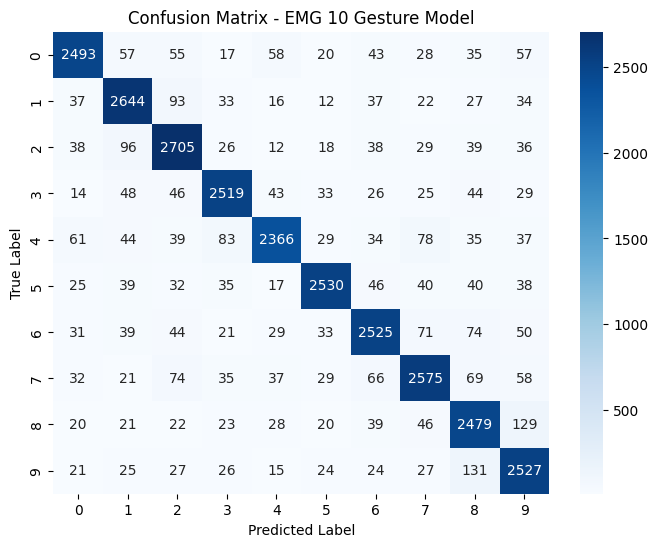

In [16]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - EMG 10 Gesture Model")
plt.show()